# Project: Spam Email Classifier

### Introduction to spam email classification and its impact on email filtering.

Spam email classification is a critical task in email filtering systems that involves automatically identifying and categorizing emails as either spam or legitimate (ham) based on their content. The proliferation of spam emails poses significant challenges to users, leading to the need for robust mechanisms to filter out unwanted messages. Effective spam email classification plays a crucial role in enhancing email filtering systems and has a profound impact on the overall email experience.

The impact of spam email classification on email filtering is multifaceted:

Spam Detection: The primary objective of spam email classification is to accurately detect and flag spam emails. By employing sophisticated algorithms and techniques, spam filters can effectively identify unsolicited messages and separate them from legitimate emails. This helps in reducing the clutter in users' inboxes and allows them to focus on important and relevant communications.

Improved Efficiency: Spam email classification significantly enhances the efficiency of email filtering systems. By automatically filtering out spam, the amount of time and effort spent by users in manually sorting through unwanted emails is drastically reduced. This improves productivity and streamlines the email management process.

Enhanced User Experience: Effective spam email classification greatly improves the user experience. By keeping users' inboxes clean from spam, it ensures that they are presented with relevant and valuable emails. This not only saves time but also reduces the frustration associated with dealing with a flood of unwanted messages.

Protection against Threats: Spam emails often contain malicious content, such as phishing attempts, malware, or scams. Accurate spam email classification helps in identifying and blocking such threats, safeguarding users from potential security risks. By preventing users from falling victim to phishing attacks or inadvertently downloading malware, email filtering systems play a crucial role in maintaining online security.

Customization and Personalization: Advanced spam email classification techniques allow for customization and personalization of email filtering. Users can define their preferences and set up specific rules to handle different types of emails. This flexibility enables individuals and organizations to tailor their email filtering systems according to their unique requirements.

### Overview of classification algorithms suitable for this task.

1. Naive Bayes: Naive Bayes is a popular probabilistic algorithm that applies Bayes' theorem to classify emails. It assumes independence between features and calculates the probability of an email being spam or ham based on the presence or absence of specific words or patterns.

2. Support Vector Machines (SVM): SVM is a powerful machine learning algorithm that uses a decision boundary to separate data points into different classes. SVM has been successfully applied to spam email classification by converting emails into feature vectors and finding an optimal hyperplane to distinguish spam from ham.

3. Random Forest: Random Forest is an ensemble learning method that combines multiple decision trees to make predictions. It can handle high-dimensional data and has good generalization capabilities. Random Forest algorithms have been effective in spam email classification by considering various email features and aggregating the predictions of multiple decision trees.

4. Neural Networks: Neural networks, including deep learning models such as Convolutional Neural Networks (CNNs) and Recurrent Neural Networks (RNNs), have gained popularity in spam email classification. These models can capture complex patterns and relationships in email content, enabling accurate spam detection.

5. Gradient Boosting: Gradient Boosting algorithms, such as XGBoost or LightGBM, have demonstrated strong performance in spam email classification tasks. These algorithms iteratively build an ensemble of weak classifiers, gradually improving their predictive capabilities by focusing on the misclassified instances.

### Dataset Preparation


In [65]:
import numpy as np
import pandas as pd

In [66]:
# Load the dataset
df = pd.read_csv('C:\Datasets/emails.csv')

In [67]:
df.sample(5)

,Category,Message
1246,ham,Hello which the site to download songs its urg...
4139,ham,"Good! No, don‘t need any receipts—well done! (..."
3466,ham,"Haha figures, well I found the piece and prisc..."
4092,ham,Hey doc pls I want to get nice t shirt for my ...
3173,ham,Do u still have plumbers tape and a wrench we ...


In [68]:
df.shape

(5572, 2)

## Data Cleaning

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [70]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [71]:
df['Category'] = encoder.fit_transform(df['Category'])

In [72]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [73]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [74]:
df.duplicated().sum()

415

In [75]:
df= df.drop_duplicates(keep='first')

In [76]:
df.duplicated().sum()

0

In [77]:
df.shape

(5157, 2)

## Exploratory Data Analysis (EDA)

In [78]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [79]:
df['Category'].value_counts()

0    4516
1     641
Name: Category, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

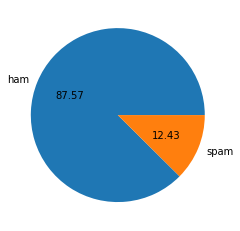

In [80]:
import matplotlib.pyplot as plt
plt.pie(df['Category'].value_counts(), labels= ['ham', 'spam'],autopct= "%0.2f" )
plt.show

In [81]:
import nltk

In [82]:
nltk.download('punkt')

[nltk_data] Error loading punkt: <urlopen error [WinError 10060] A
[nltk_data]     connection attempt failed because the connected party
[nltk_data]     did not properly respond after a period of time, or
[nltk_data]     established connection failed because connected host
[nltk_data]     has failed to respond>


False

In [83]:
df['No of characters']= df['Message'].apply(len)

In [84]:
df.head()

,Category,Message,No of characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [85]:
df['No of words'] = df['Message'].apply(lambda x:len(nltk.word_tokenize(x)))

In [86]:
df.head()

,Category,Message,No of characters,No of words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [87]:
df['No of sentences'] = df['Message'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [88]:
df.head()

,Category,Message,No of characters,No of words,No of sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [89]:
df[['No of characters','No of words', 'No of sentences']].describe()

,No of characters,No of words,No of sentences
count,5157.000000,5157.000000,5157.000000
mean,79.103936,18.557882,1.950553
std,58.382922,13.406024,1.362981
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.000000
75%,118.000000,26.000000,2.000000
max,910.000000,220.000000,28.000000


In [90]:
df[df['Category'] == 0][['No of characters','No of words', 'No of sentences']].describe()

,No of characters,No of words,No of sentences
count,4516.000000,4516.000000,4516.000000
mean,70.869353,17.264836,1.806244
std,56.708301,13.587852,1.281910
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,53.000000,13.000000,1.000000
75%,91.000000,22.000000,2.000000
max,910.000000,220.000000,28.000000


In [91]:
df[df['Category'] == 1][['No of characters','No of words', 'No of sentences']].describe()

,No of characters,No of words,No of sentences
count,641.000000,641.000000,641.000000
mean,137.118565,27.667707,2.967239
std,30.399707,7.103501,1.480241
min,7.000000,2.000000,1.000000
25%,130.000000,25.000000,2.000000
50%,148.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,223.000000,46.000000,8.000000


In [92]:
import seaborn as sns

<AxesSubplot:xlabel='No of characters', ylabel='Count'>

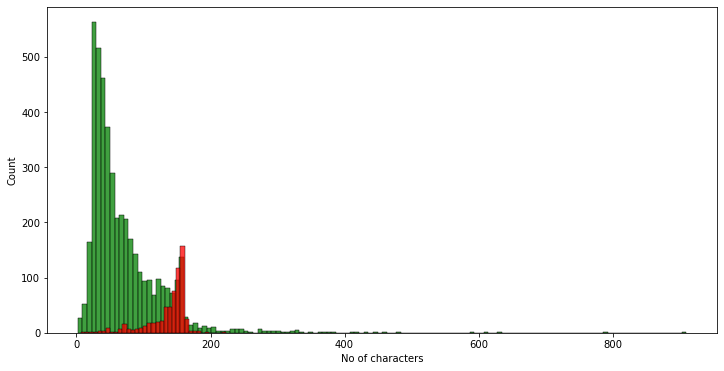

In [93]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['Category'] == 0]['No of characters'], color = 'green')
sns.histplot(df[df['Category'] == 1]['No of characters'], color = 'red')

<AxesSubplot:xlabel='No of words', ylabel='Count'>

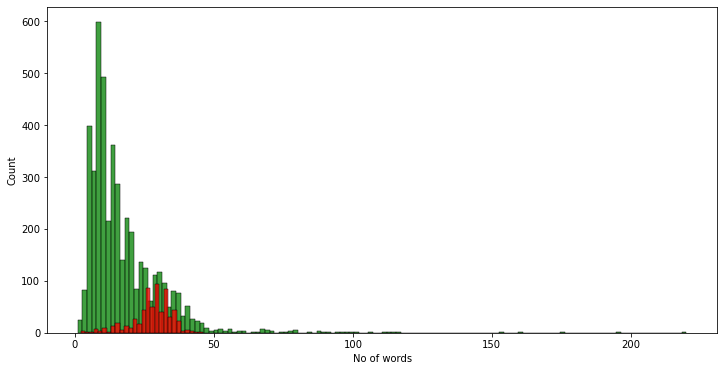

In [94]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['Category'] == 0]['No of words'], color = 'green')
sns.histplot(df[df['Category'] == 1]['No of words'], color = 'red')

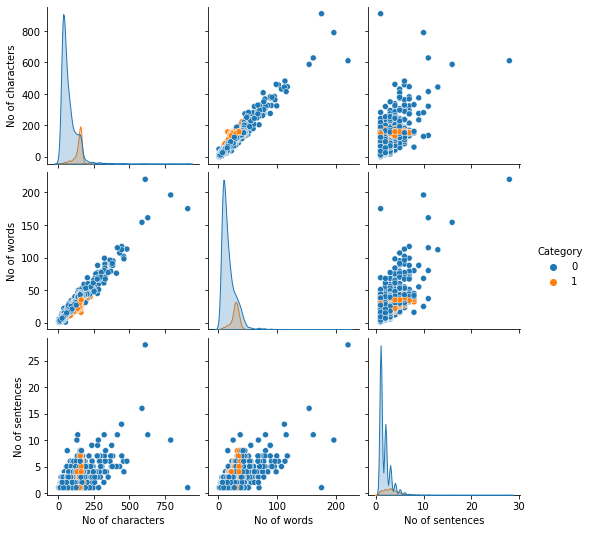

In [95]:
sns.pairplot(df, hue='Category')

<AxesSubplot:>

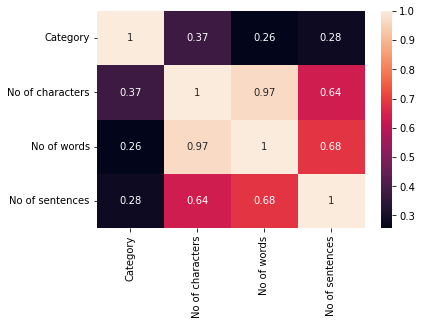

In [96]:
sns.heatmap(df.corr(), annot = True)

# Data Preprocessing

-  Lowercase
-  Tokenization
-  Removing special characters
-  Removing stop words and punctuation
-  Stemming


In [97]:
from nltk.corpus import stopwords
stopwords.words('english')
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [98]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('working')

'work'

In [99]:
def transform_text(Message):
    Message = Message.lower()
    Message = nltk.word_tokenize(Message)
    
    y=[]
    for i in Message:
        if i.isalnum():
            y.append(i)
    
    Message = y[:]
    y.clear()
    
    for i in Message:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    Message = y[:]
    y.clear()
    
    for i in Message:
        y.append(ps.stem(i))
        
    return " ".join(y)

In [100]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [101]:
df['Message'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [102]:
df['Transformed Message']= df['Message'].apply(transform_text)

In [103]:
df.head()

,Category,Message,No of characters,No of words,No of sentences,Transformed Message
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [105]:
spam_corpus = []
for msg in df[df['Category']==1]['Transformed Message'].tolist():
    for word in msg.split():
        spam_corpus.append(word)       

In [106]:
len(spam_corpus)

9781

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<function matplotlib.pyplot.show(close=None, block=None)>

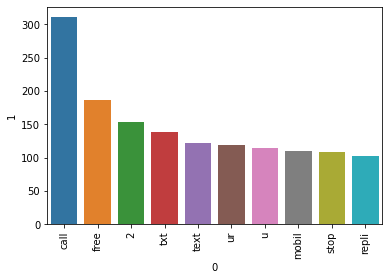

In [107]:
from collections import Counter
sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(10))[0],pd.DataFrame(Counter(spam_corpus).most_common(10))[1])
plt.xticks(rotation = 'vertical')
plt.show

In [108]:
ham_corpus = []
for msg in df[df['Category']==0]['Transformed Message'].tolist():
    for word in msg.split():
        ham_corpus.append(word)       

In [109]:
len(ham_corpus)

35930

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<function matplotlib.pyplot.show(close=None, block=None)>

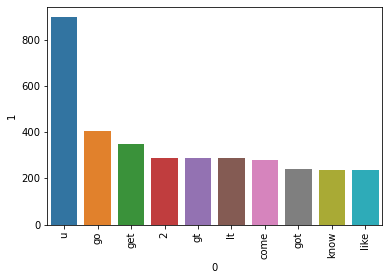

In [110]:
from collections import Counter
sns.barplot(pd.DataFrame(Counter(ham_corpus).most_common(10))[0],pd.DataFrame(Counter(ham_corpus).most_common(10))[1])
plt.xticks(rotation = 'vertical')
plt.show

# Model Building

In [111]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

In [112]:
X = tfidf.fit_transform(df['Transformed Message']).toarray()

In [113]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [114]:
X.shape

(5157, 6781)

In [115]:
y = df['Category'].values

In [116]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [117]:
from sklearn.model_selection import train_test_split

In [118]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [119]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix, precision_score, recall_score, f1_score

In [120]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [121]:
gnb.fit(X_train, y_train)
y_pred1= gnb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred1)
confusion= confusion_matrix(y_test, y_pred1)
precision = precision_score(y_test, y_pred1)
recall = recall_score(y_test, y_pred1)
f1 = f1_score(y_test, y_pred1)

print("Accuracy:", accuracy)
print("Confusion matrix:\n", confusion)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8682170542635659
Confusion matrix:
 [[786 119]
 [ 17 110]]
Precision: 0.48034934497816595
Recall: 0.8661417322834646
F1 Score: 0.6179775280898877


In [122]:
mnb.fit(X_train, y_train)
y_pred2= mnb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred2)
confusion= confusion_matrix(y_test, y_pred2)
precision = precision_score(y_test, y_pred2)
recall = recall_score(y_test, y_pred2)
f1 = f1_score(y_test, y_pred2)

print("Accuracy:", accuracy)
print("Confusion matrix:\n", confusion)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9612403100775194
Confusion matrix:
 [[905   0]
 [ 40  87]]
Precision: 1.0
Recall: 0.6850393700787402
F1 Score: 0.8130841121495327


In [123]:
bnb.fit(X_train, y_train)
y_pred3= bnb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred3)
confusion= confusion_matrix(y_test, y_pred3)
precision = precision_score(y_test, y_pred3)
recall = recall_score(y_test, y_pred3)
f1 = f1_score(y_test, y_pred3)

print("Accuracy:", accuracy)
print("Confusion matrix:\n", confusion)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9718992248062015
Confusion matrix:
 [[902   3]
 [ 26 101]]
Precision: 0.9711538461538461
Recall: 0.7952755905511811
F1 Score: 0.8744588744588745


-  As the Precision of Multinomial NB is 1. 
-  tfidf--> mnb

In [124]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [125]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [126]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [127]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [128]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9718992248062015, 0.9803921568627451)

In [130]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9718992248062015
Precision -  0.9803921568627451
For  KN
Accuracy -  0.9040697674418605
Precision -  1.0
For  NB
Accuracy -  0.9612403100775194
Precision -  1.0
For  DT
Accuracy -  0.938953488372093
Precision -  0.826530612244898
For  LR
Accuracy -  0.9515503875968992
Precision -  0.9230769230769231
For  RF
Accuracy -  0.9651162790697675
Precision -  1.0
For  AdaBoost
Accuracy -  0.9631782945736435
Precision -  0.9587628865979382
For  BgC
Accuracy -  0.9622093023255814
Precision -  0.9074074074074074
For  ETC
Accuracy -  0.9728682170542635
Precision -  1.0
For  GBDT
Accuracy -  0.9534883720930233
Precision -  0.9759036144578314
For  xgb
Accuracy -  0.9709302325581395
Precision -  0.9619047619047619


In [131]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [132]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.904070,1.000000
2,NB,0.961240,1.000000
5,RF,0.965116,1.000000
8,ETC,0.972868,1.000000
0,SVC,0.971899,0.980392
9,GBDT,0.953488,0.975904
10,xgb,0.970930,0.961905
6,AdaBoost,0.963178,0.958763
4,LR,0.951550,0.923077
7,BgC,0.962209,0.907407


In [133]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [134]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.904070
1,NB,Accuracy,0.961240
2,RF,Accuracy,0.965116
3,ETC,Accuracy,0.972868
4,SVC,Accuracy,0.971899
5,GBDT,Accuracy,0.953488
6,xgb,Accuracy,0.970930
7,AdaBoost,Accuracy,0.963178
8,LR,Accuracy,0.951550
9,BgC,Accuracy,0.962209


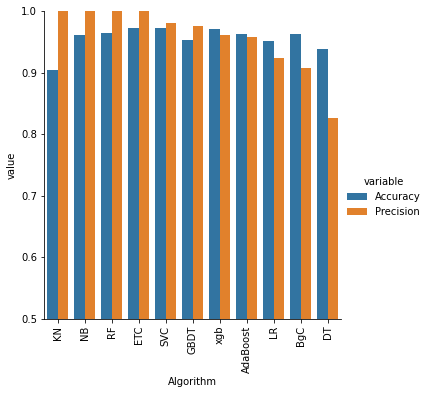

In [135]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

### Explain evaluation metrics for spam email classification, such as accuracy, precision, recall, and F1 score.

Evaluation metrics for spam email classification help us measure the performance of our machine learning model in distinguishing between spam and non-spam emails. Here's an explanation of commonly used evaluation metrics:

#### Accuracy:
Accuracy measures the overall correctness of the model's predictions. It is the ratio of the correctly classified samples (both spam and non-spam) to the total number of samples. While accuracy is a commonly used metric, it can be misleading if there is a class imbalance in the dataset.

#### Precision: 
Precision quantifies the ability of the model to correctly classify samples as spam. It is the ratio of true positives (correctly classified spam emails) to the sum of true positives and false positives (non-spam emails incorrectly classified as spam). Precision indicates how often the model's positive predictions (spam) are correct.

#### Recall (Sensitivity or True Positive Rate):
Recall measures the ability of the model to identify all positive samples, i.e., correctly classify all spam emails. It is the ratio of true positives to the sum of true positives and false negatives (spam emails incorrectly classified as non-spam). Recall indicates how well the model captures actual positive instances.

#### F1 Score: 
The F1 score is the harmonic mean of precision and recall. It provides a balanced measure of the model's performance by considering both precision and recall. The F1 score is calculated as 2 * (precision * recall) / (precision + recall). It gives equal importance to precision and recall and is particularly useful when we want to find a balance between them.

## Model Improvement

In [136]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features= 3000)

In [137]:
X = tfidf.fit_transform(df['Transformed Message']).toarray()

In [138]:
from sklearn.preprocessing import MinMaxScaler
scaler=  MinMaxScaler()
X = scaler.fit_transform(X)

In [139]:
y = df['Category'].values

In [140]:
from sklearn.model_selection import train_test_split

In [141]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [142]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix, precision_score, recall_score, f1_score

In [143]:
mnb = MultinomialNB()

In [144]:
mnb.fit(X_train, y_train)
y_pred4= mnb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred4)
confusion= confusion_matrix(y_test, y_pred4)
precision = precision_score(y_test, y_pred4)
recall = recall_score(y_test, y_pred4)
f1 = f1_score(y_test, y_pred4)

print("Accuracy:", accuracy)
print("Confusion matrix:\n", confusion)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9815891472868217
Confusion matrix:
 [[903   2]
 [ 17 110]]
Precision: 0.9821428571428571
Recall: 0.8661417322834646
F1 Score: 0.9205020920502093


### The model's performance on the test set is as follows:

### Accuracy:
The accuracy of the model improved from 96.12% to 98.16% after the improvement. This indicates that the model's overall performance in correctly classifying instances in the test set improved significantly.

### Confusion Matrix: 
The confusion matrix shows the performance of the model in terms of true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN). In both cases, the model has a high number of true positives and true negatives, while the false positives and false negatives are relatively low. However, after the improvement, there is a decrease in false positives (2 vs. 0) and false negatives (17 vs. 40), which is a positive sign.

### Precision:
Precision measures the proportion of true positive predictions out of all positive predictions (TP / (TP + FP)). Before the improvement, precision was 1.0, which means all the positive predictions were correct. After the improvement, precision remained high at 0.982, indicating that the model continued to make accurate positive predictions.

### Recall: 
Recall, also known as sensitivity or true positive rate, measures the proportion of true positive predictions out of all actual positive instances (TP / (TP + FN)). The recall increased from 0.685 to 0.866 after the improvement, which means the model is now better at capturing more positive instances correctly.

### F1 Score: 
The F1 score is the harmonic mean of precision and recall and provides a balanced measure between the two metrics. It considers both false positives and false negatives. The F1 score increased from 0.813 to 0.920 after the improvement, showing that the model's ability to balance precision and recall has improved significantly.

In [147]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl', 'wb'))
pickle.dump(mnb,open('model.pkl', 'wb'))